# Exploratory Data Analysis

Exploratory Data Analysis (EDA) is an analytical approach aimed at uncovering the inherent characteristics of datasets, utilizing statistical and visualization techniques.

## EDA Functions

In [ ]:
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]] # For displaying purposes, pick columns that have between 1 and 50 unique values
    nRow, nCol = df.shape
    columnNames = list(df)
    nGraphRow = (nCol + nGraphPerRow - 1) // nGraphPerRow
    plt.figure(num = None, figsize = (6 * nGraphPerRow, 8 * nGraphRow), dpi = 80, facecolor = 'w', edgecolor = 'k')
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        columnDf = df.iloc[:, i]
        if (not np.issubdtype(type(columnDf.iloc[0]), np.number)):
            valueCounts = columnDf.value_counts()
            valueCounts.plot.bar()
        else:
            columnDf.hist()
        plt.ylabel('counts')
        plt.xticks(rotation = 90)
        plt.title(f'{columnNames[i]} (column {i})')
    plt.tight_layout(pad = 1.0, w_pad = 1.0, h_pad = 1.0)
    plt.show()

In [ ]:
def plotCorrelationMatrix(df, graphWidth):
    filename = str(getattr(df, 'dataframeName', 'DataFrame'))
    graphWidth = float(graphWidth)

    df = df.dropna(axis='columns')
    df = df[[col for col in df if df[col].nunique() > 1]]

    if df.shape[1] < 2:
        print(f'No correlation plots shown: The number of non-NaN or constant columns ({df.shape[1]}) is less than 2')
        return

    corr = df.corr(numeric_only=True)

    plt.figure(figsize=(graphWidth, graphWidth), dpi=80)
    corrMat = plt.matshow(corr)  # ✅ removed fignum=1
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.gca().xaxis.tick_bottom()
    plt.colorbar(corrMat)
    plt.title(f'Correlation Matrix for {filename}', fontsize=15)
    plt.show()

In [ ]:
def plotScatterMatrix(df, plotSize, textSize):
    df = df.select_dtypes(include=[np.number])  # only numeric columns
    df = df.dropna(axis='columns')
    df = df[[col for col in df if df[col].nunique() > 1]]

    columnNames = list(df)
    if len(columnNames) > 10:
        columnNames = columnNames[:10]
    df = df[columnNames]

    ax = pd.plotting.scatter_matrix(df, alpha=0.75, figsize=[plotSize, plotSize], diagonal='kde')

    corrs = df.corr().values
    for i, j in zip(*np.triu_indices_from(corrs, k=1)):
        ax[i, j].annotate(f'Corr = {corrs[i, j]:.3f}', (0.8, 0.2),
                          xycoords='axes fraction',
                          ha='center', va='center', size=textSize)

    plt.suptitle('Scatter and Density Plot')
    plt.show()

In [ ]:
def univariate_analysis(df):
    num_cols = df.select_dtypes(include=[np.number]).columns
    print("\n### Numerical Columns Summary ###")
    for col in num_cols:
        print(f"\n--- {col} ---")
        print("Summary Statistics:")
        print(df[col].describe())
        print(f"Missing Values: {df[col].isnull().sum()}")
        print(f"Unique Values: {df[col].nunique()}")

        # Plot Histogram and Boxplot
        plt.figure(figsize=(12, 6))

        plt.subplot(1, 2, 1)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f'{col} - Distribution')

        plt.subplot(1, 2, 2)
        sns.boxplot(x=df[col])
        plt.title(f'{col} - Boxplot')

        plt.tight_layout()
        plt.show()

    # Categorical Columns
    cat_cols = df.select_dtypes(include=[object, 'category']).columns  # ✅ Fix: replace np.object with object
    print("\n### Categorical Columns Summary ###")
    for col in cat_cols:
        print(f"\n--- {col} ---")
        print("Frequency Distribution:")
        print(df[col].value_counts())
        print(f"Missing Values: {df[col].isnull().sum()}")
        print(f"Unique Values: {df[col].nunique()}")

        # Plot Barplot
        plt.figure(figsize=(6, 4))
        sns.countplot(x=df[col])
        plt.title(f'{col} - Frequency Distribution')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

## EDA using ProfileReport

In [ ]:
# profile = ProfileReport(df,title="creditcard Profile")

# profile.to_file("creditcard.html")

[HTML LINK](https://drive.google.com/file/d/1dhuZN9DSIEQ4DPOQJhGU-8TZPBGMMov1/view?usp=drive_link)

refrance : [medium EDA](https://medium.com/data-science/a-data-scientists-essential-guide-to-exploratory-data-analysis-25637eee0cf6)

In [ ]:
# !pip install sweetviz
# !pip install numpy==1.24.4
# import sweetviz as sv
# import warnings
# report = sv.analyze(df)
# report.show_html("sweetviz_report.html")

[HTML LINK](https://drive.google.com/file/d/1IyvARdWBOqluJXmQsxBZezDEfMhrB06T/view?usp=drive_link)

## EDA CODE

### Print DataFrame first five rows

since all non fraud are outliers, outliers will not be removed.

In [ ]:
XT = np.array(X).transpose()

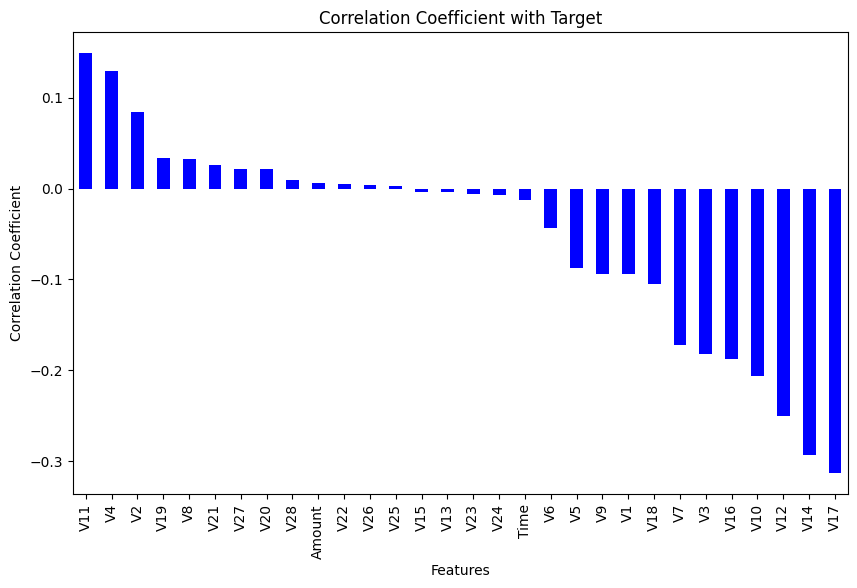

In [ ]:
# Correlation Coefficient
corr_scores = np.corrcoef(XT, Y)[-1, :-1]  # Correlation with target
corr_scores = pd.Series(corr_scores, index=feature_names)
corr_scores.sort_values(ascending=False, inplace=True)

# Plot Correlation Coefficients
plt.figure(figsize=(10, 6))
corr_scores.plot(kind="bar", color="blue")
plt.title("Correlation Coefficient with Target")
plt.xlabel("Features")
plt.ylabel("Correlation Coefficient")
plt.show()

### Univariant analysis

In [ ]:
univariate_analysis(df)

### Varianve threshold

In [ ]:
variance_threshold = VarianceThreshold(threshold=1)  # Remove low-variance features
X_variance_selected = variance_threshold.fit_transform(X)

# Get selected features
selected_features = variance_threshold.get_support(indices=True)
print("Selected Features (Variance Threshold):", [feature_names[i] for i in selected_features])

Selected Features (Variance Threshold): ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'Amount']


### ANOVA (F-test)

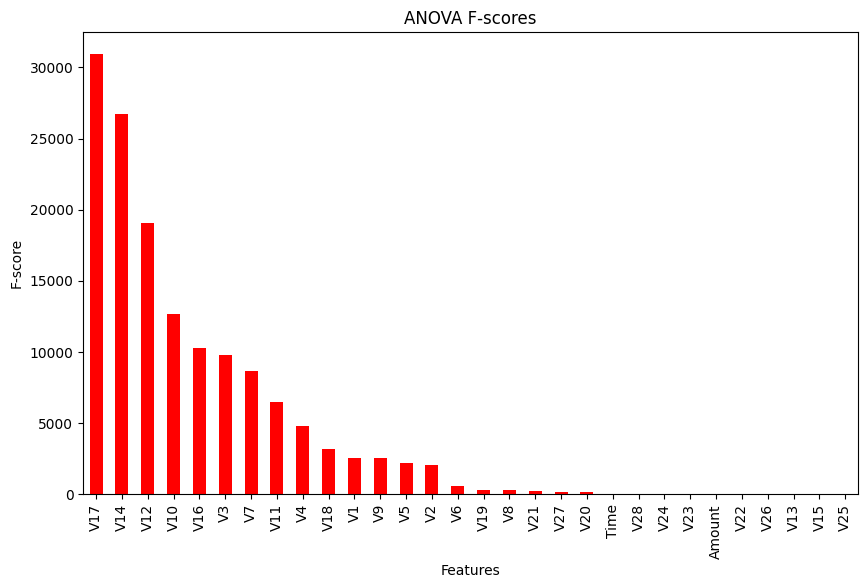

In [ ]:
# ANOVA (F-test)
f_scores, _ = f_classif(X, Y)  # ANOVA F-test
f_scores = pd.Series(f_scores, index=feature_names)
f_scores.sort_values(ascending=False, inplace=True)

# Plot ANOVA F-scores
plt.figure(figsize=(10, 6))
f_scores.plot(kind="bar", color="red")
plt.title("ANOVA F-scores")
plt.xlabel("Features")
plt.ylabel("F-score")
plt.show()

# Data augmentation

In the next cell we will see why we need data augmentation and sampling

In [ ]:
len(df[df['Class']==1])

473

In [ ]:
len(df[df['Class']==0])

283253

data is unbalanced

In [ ]:
# pip install imblearn

In [ ]:
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, Y)

In [ ]:
len(y_resampled[y_resampled==0])

284315

In [ ]:
len(y_resampled[y_resampled==1])

284315

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Wrapper Methods Feature Selection Techniques

The paper employed Correlation matrix (heatmap) analysis to identify and remove highly correlated features that may contribute to multicollinearity.

## LR

In [ ]:
# ---- 1. Forward Feature Selection (FSF) ----
fsf_selector = SelectKBest(score_func=f_classif, k=10)  # Select top 5 features
X_new_fsf = fsf_selector.fit_transform(X_resampled, y_resampled)
selected_fsf_features = X.columns[fsf_selector.get_support()]

print("Forward Feature Selection Features:", selected_fsf_features.tolist())

Forward Feature Selection Features: ['V2', 'V3', 'V4', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17']


In [ ]:
FSF = ['V2', 'V3', 'V4', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17']

In [ ]:
# ---- 2. Recursive Feature Elimination ----

log_reg = LogisticRegression(max_iter=500, solver='liblinear')
rfe_selector = RFE(log_reg, n_features_to_select=10)  # Select top 5 features
rfe_selector.fit(X_resampled, y_resampled)
selected_rfe_features = X.columns[rfe_selector.support_]

# Results
print("Recursive Feature Elimination Features:", selected_rfe_features.tolist())

Recursive Feature Elimination Features: ['V4', 'V10', 'V11', 'V12', 'V13', 'V14', 'V16', 'V17', 'V27', 'V28']


In [ ]:
RFF = ['V4', 'V10', 'V11', 'V12', 'V13', 'V14', 'V16', 'V17', 'V27', 'V28']

## RF

In [ ]:


# Train a Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_resampled, y_resampled)

# Use feature importances to select top features
sfm = SelectFromModel(rf_model, prefit=True, threshold="median")  # Select features above the median importance
X_new_sfm = sfm.transform(X_resampled)
selected_rf_features = X_resampled.columns[sfm.get_support()]

print("Selected Features by RF + SelectFromModel:", selected_rf_features.tolist())


Selected Features by RF + SelectFromModel: ['V1', 'V2', 'V3', 'V4', 'V6', 'V7', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V21']


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [ ]:
RFSM = ['V1', 'V2', 'V3', 'V4', 'V6', 'V7', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V21']